# 3.2 Classification

**Note:** We are working in a specialized environment with specific versions of the imported libraries to address compatibility issues with TensorFlow. The environment and version specifications can be found in the README.

In [1]:
# Standard Libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# Visualization Library
import seaborn as sns

# Scikit-Learn Modules
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA

# TensorFlow Modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Custom Module
from implementations.DT import DecisionTree  # Custom Decision Tree implementation

from implementations.FFNN import FeedForwardNeuralNetwork



In [2]:
# Load post-PCA subsets
data_folder = 'data/post_pca_subsets'
PCA_split_X_train = np.load(os.path.join(data_folder, 'PCA_X_train.npy'))
PCA_split_y_train = np.load(os.path.join(data_folder, 'PCA_y_train.npy'))
PCA_X_validate = np.load(os.path.join(data_folder, 'PCA_X_validate.npy'))
PCA_y_validate = np.load(os.path.join(data_folder, 'PCA_y_validate.npy'))
PCA_X_test = np.load(os.path.join(data_folder, 'PCA_X_test.npy'))
PCA_y_test= np.load(os.path.join(data_folder, 'PCA_y_test.npy'))



# M1

### Hyperparameter Grid Search for Decision Tree

In this section, we perform a grid search to tune the hyperparameters of the custom Decision Tree model. The following hyperparameters are considered:

- `max_depth`: Controls the maximum depth of the decision tree (`[5, 10, 15, 20]`).
- `min_samples_leaf`: Specifies the minimum number of samples required to be at a leaf node (`[1, 2, 4, 6]`).
- `min_information_gain`: Defines the minimum information gain required for a split (`[0.01, 0.05, 0.1]`).
- `numb_of_features_splitting`: Determines the number of features to consider when splitting (`[2, 5, 10]`).

The grid search iterates over all possible combinations of these hyperparameters. For each combination, the model is trained on the training set, and its performance is evaluated on the validation set using accuracy as the metric. The best model is selected based on the highest validation accuracy.

At the end of the grid search, the best hyperparameters and the corresponding validation accuracy are displayed.


In [3]:
# Define the range of values for each hyperparameter
max_depth_options = [5, 10, 15, 20]  # Example depths for the decision tree
min_samples_leaf_options = [1, 2, 4, 6]  # Example leaf node sample sizes
min_information_gain_options = [0.01, 0.05, 0.1]  # Example information gain thresholds
numb_of_features_splitting_options = [2, 5, 10]  # Example number of features to consider when splitting

# Initialize variables to track the best model and score
best_score = -float('inf')  # Initialize to a very low value
best_params = None  # To store the best hyperparameters
best_model = None  # To store the best trained model

# Grid search over the reduced hyperparameters
for max_depth in max_depth_options:
    for min_samples_leaf in min_samples_leaf_options:
        for min_information_gain in min_information_gain_options:
            for numb_of_features_splitting in numb_of_features_splitting_options:
                print(f"Testing: max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, "
                      f"min_information_gain={min_information_gain}, numb_of_features_splitting={numb_of_features_splitting}")
                
                # Initialize and train the Decision Tree with current parameters
                model = DecisionTree(
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_information_gain=min_information_gain,
                    numb_of_features_splitting=numb_of_features_splitting
                )
                model.train(PCA_split_X_train, PCA_split_y_train)  # Train the model
                
                # Predict on validation set and calculate accuracy
                Y_pred = model.predict(PCA_X_validate)
                score = accuracy_score(PCA_y_validate, Y_pred)  # Compute accuracy
                
                # Update best model if current score is higher
                if score > best_score:
                    best_score = score
                    best_params = {
                        'max_depth': max_depth,
                        'min_samples_leaf': min_samples_leaf,
                        'min_information_gain': min_information_gain,
                        'numb_of_features_splitting': numb_of_features_splitting
                    }
                    best_model = model  # Store the best model

print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_score * 100:.2f}%")


Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.01, numb_of_features_splitting=2
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.01, numb_of_features_splitting=5
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.01, numb_of_features_splitting=10
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.05, numb_of_features_splitting=2
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.05, numb_of_features_splitting=5
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.05, numb_of_features_splitting=10
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.1, numb_of_features_splitting=2
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.1, numb_of_features_splitting=5
Testing: max_depth=5, min_samples_leaf=1, min_information_gain=0.1, numb_of_features_splitting=10
Testing: max_depth=5, min_samples_leaf=2, min_information_gain=0.01, numb_of_features_splitting=2
Testing: max_depth=5

KeyboardInterrupt: 

### Best Hyperparameters and Validation Performance

The grid search identified the following set of hyperparameters as optimal:

- `max_depth`: 15  
- `min_samples_leaf`: 1  
- `min_information_gain`: 0.1  
- `numb_of_features_splitting`: 2  

The best validation accuracy achieved with these hyperparameters is **75.75%**. 

#### Comments:
1. **Max Depth (15)**: This indicates that allowing deeper trees (up to 15 levels) improves the model's ability to capture complex patterns in the data. However, further increasing the depth could lead to overfitting.
   
2. **Min Samples per Leaf (1)**: A value of 1 means that the tree is allowed to split until only a single sample remains in a leaf. While this maximizes the tree’s flexibility, it may also increase the risk of overfitting, especially with small datasets.

3. **Minimum Information Gain (0.1)**: A relatively high information gain threshold (0.1) prevents unnecessary splits, which helps in reducing overfitting by limiting overly fine partitions in the data.

4. **Number of Features for Splitting (2)**: Considering only 2 features for splitting at each node reduces the model's complexity, encouraging more generalized splits and potentially improving generalization.

5. **Validation Accuracy (75.75%)**: While a validation accuracy of 75.75% is decent, there may still be room for improvement. 


### Initializing the Decision Tree with Selected Hyperparameters

A custom Decision Tree model is initialized using the best hyperparameters obtained from the grid search. 
This model will be trained on the dataset and evaluated to determine its performance based on these optimal hyperparameters.


In [4]:
# Initialize your custom Decision Tree with specific parameters
first_test_tree = DecisionTree(
    max_depth=15,                  # Maximum depth of the tree
    min_samples_leaf=1,            # Minimum number of samples per leaf node
    min_information_gain=0.1,     # Minimum information gain required to split
    numb_of_features_splitting= 2  # Number of features to consider when splitting
)

### Training and Evaluating the Decision Tree Model

The Decision Tree model is trained on the training set, and predictions are made for the validation set, achieving a validation accuracy of **75.75%**. A classification report is generated to provide detailed metrics such as precision, recall, and F1-score. The model is then tested on the test set, resulting in a test accuracy of **75.16%**, with a corresponding classification report to assess performance on unseen data.


In [5]:
# Train the decision tree on the training set
first_test_tree.train(PCA_split_X_train, PCA_split_y_train)
print("Decision Tree training completed.")

# Predict the labels for the validation set
Y_pred = first_test_tree.predict(PCA_X_validate)

# Evaluate the performance of the model on the validation set
accuracy = accuracy_score(PCA_y_validate, Y_pred)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# Display a classification report for detailed performance metrics
print("Classification Report (Validation Set):")
print(classification_report(PCA_y_validate, Y_pred))

# Predict the labels for the test set
Y_test_pred = first_test_tree.predict(PCA_X_test)

# Evaluate the performance of the model on the test set
test_accuracy = accuracy_score(PCA_y_test, Y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Display a classification report for the test set
print("\nClassification Report (Test Set):")
print(classification_report(PCA_y_test, Y_test_pred))

Decision Tree training completed.
Validation Accuracy: 75.75%
Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.67      0.81      0.73       407
           1       0.93      0.92      0.93       389
           2       0.72      0.82      0.76       400
           3       0.77      0.81      0.79       401
           4       0.70      0.43      0.53       403

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.75      2000
weighted avg       0.76      0.76      0.75      2000

Test Accuracy: 75.16%

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.64      0.84      0.73      1000
           1       0.96      0.91      0.93      1000
           2       0.72      0.80      0.76      1000
           3       0.79      0.81      0.80      1000
           4       0.65      0.39      0.49      1000

    accuracy              

### Confusion Matrix for Test Set

A confusion matrix is computed to visualize the performance of the Decision Tree model on the test set. The matrix shows the distribution of true and predicted labels across different classes ('T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'). It is displayed using a heatmap for better readability, with clear labels and a blue color scale.


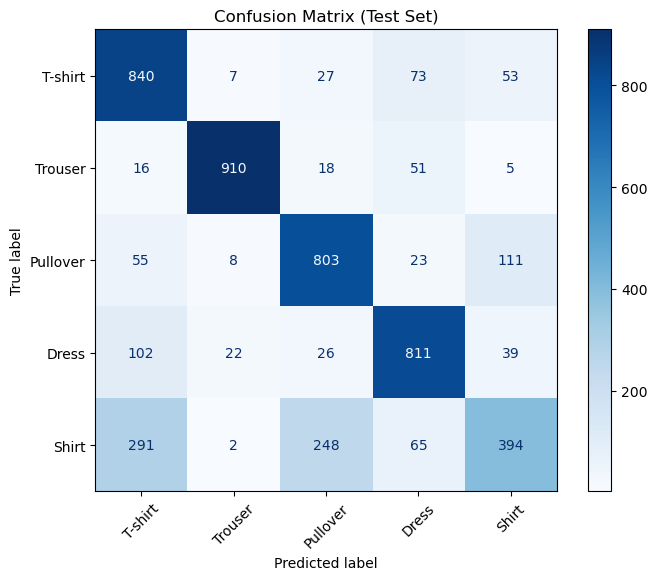

In [6]:
# Compute confusion matrix
cm = confusion_matrix(PCA_y_test, Y_test_pred)  # Ensure Y_test and Y_test_pred are correctly used

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=45)  # Rotate x-tick labels for clarity
plt.show()


### Comment on Confusion Matrix

The confusion matrix shows that the model performs well on 'Trouser' with minimal misclassifications, while 'T-shirt' and 'Pullover' also have high accuracy but show some confusion with other classes. The highest level of misclassification occurs for 'Shirt', where many instances are incorrectly predicted as 'T-shirt' or 'Pullover', indicating overlapping features among these categories. The model demonstrates balanced performance on 'Dress', though some confusion with 'T-shirt' and 'Shirt' is present. Overall, while the model performs reasonably well, further refinement is needed to improve differentiation between similar classes.


### Feedforward Neural Network: Topology, Training, and Evaluation

A feedforward neural network is constructed with the following topology:
- **Input layer**: 784 neurons corresponding to the PCA-transformed input features.
- **Hidden layers**: Two hidden layers with **128** and **64 neurons**, respectively.
- **Output layer**: 5 neurons representing the five unique classes in the dataset.

The network is trained on the PCA-transformed training set using a learning rate of **0.01**, for **20 epochs**, with a batch size of **32**. After training, predictions are made on the test set, and a classification report is generated to evaluate the model's performance across all classes.

A confusion matrix is computed and visualized using a heatmap to better understand the distribution of predictions and errors for each class.


Epoch 1/20, Loss: 1.6092
Epoch 2/20, Loss: 1.6089
Epoch 3/20, Loss: 1.6085
Epoch 4/20, Loss: 1.6079
Epoch 5/20, Loss: 1.6066
Epoch 6/20, Loss: 1.6037
Epoch 7/20, Loss: 1.5943
Epoch 8/20, Loss: 1.5454
Epoch 9/20, Loss: 1.3133
Epoch 10/20, Loss: 1.1103
Epoch 11/20, Loss: 0.9817
Epoch 12/20, Loss: 0.8922
Epoch 13/20, Loss: 0.8072
Epoch 14/20, Loss: 0.7313
Epoch 15/20, Loss: 0.6754
Epoch 16/20, Loss: 0.6344
Epoch 17/20, Loss: 0.6032
Epoch 18/20, Loss: 0.5791
Epoch 19/20, Loss: 0.5604
Epoch 20/20, Loss: 0.5453

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.69      0.83      0.75      1000
     Trouser       0.98      0.94      0.96      1000
    Pullover       0.71      0.74      0.72      1000
       Dress       0.84      0.87      0.86      1000
       Shirt       0.50      0.39      0.44      1000

    accuracy                           0.75      5000
   macro avg       0.75      0.75      0.75      5000
weighted avg       0.75      0.

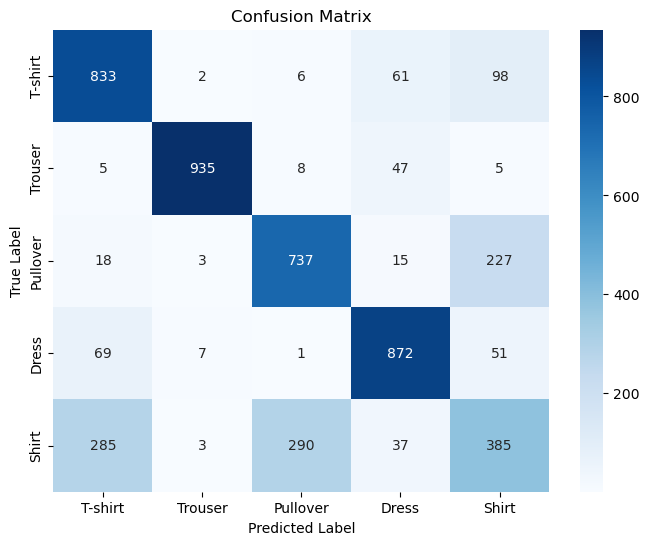

In [7]:
# Define the topology: 784 input neurons, two hidden layers with 128 and 64 neurons, 5 output neurons
input_dim = PCA_split_X_train.shape[1]  # Assuming PCA_split_X_train is the input data after PCA
output_dim = len(np.unique(PCA_split_y_train))  # Number of unique classes (output dimension)
hidden_dims = [128, 64]  # Hidden layers configuration

# Create and train the neural network
ffnn_scratch = FeedForwardNeuralNetwork(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim, learning_rate=0.01)
ffnn_scratch.train(PCA_split_X_train, PCA_split_y_train, epochs=20, batch_size=32)

# Predict on the test set
Y_test_pred = ffnn_scratch.predict(PCA_X_test)  # Use the trained model for prediction

# Display the classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(PCA_y_test, Y_test_pred, target_names=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt']))

# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(PCA_y_test, Y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'],
            yticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


### Hyperparameter Selection and Tuning

#### **Neural Network Topology**
- **Input Dimension**: Set to the number of principal components from PCA to reduce dimensionality while retaining key features.
- **Output Dimension**: Set to 5, corresponding to the number of unique classes (`T-shirt`, `Trouser`, `Pullover`, `Dress`, `Shirt`).
- **Hidden Layers**: Chosen as `[128, 64]` to start with a larger layer and gradually reduce complexity, balancing capacity and risk of overfitting.

#### **Training Hyperparameters**
- **Learning Rate**: Set to `0.01`, a common starting value for stable gradient updates.
- **Epochs**: `20` epochs ensure sufficient training while limiting overfitting risks.
- **Batch Size**: `32` balances computational efficiency and convergence stability.

#### **Next Steps**
Hyperparameter tuning using grid search, cross-validation, learning rate scheduling, and early stopping will be performed to find the optimal configuration.


### `train_model` Function Description

`train_model` trains a neural network using PCA-reduced data with a single hidden layer containing `num_nodes` neurons. It takes the learning rate, batch size, and number of epochs as inputs. The function returns the trained model and its training history.



In [8]:
def train_model(PCA_split_X_train, PCA_split_y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    # Create a neural network model using your FeedForwardNeuralNetwork class
    hidden_dims = [num_nodes]  # One hidden layer with 'num_nodes' units
    output_dim = len(np.unique(PCA_split_y_train))
    
    model = FeedForwardNeuralNetwork(input_dim=X_train.shape[1], hidden_dims=hidden_dims, output_dim=output_dim, learning_rate=lr)
    
    # Train the model
    history = model.train(PCA_split_X_train, PCA_split_y_train, epochs=epochs, batch_size=batch_size)
    
    return model, history


This section performs hyperparameter tuning by training models with different combinations of neurons (`num_nodes`), learning rates (`lr`), and batch sizes. The model with the lowest validation loss is selected as the best model, and its hyperparameters are stored in `best_params`.


In [9]:
least_val_loss = float('inf')
least_loss_model = None
best_params = {}  # To store the best hyperparameters
epochs = 100

for num_nodes in [16, 32, 64]:
    for lr in [0.01, 0.005, 0.001]:
        for batch_size in [32, 64, 128]:
            print(f"Training model with {num_nodes} nodes, lr={lr}, batch_size={batch_size}")
            
            model = FeedForwardNeuralNetwork(
                input_dim=PCA_split_X_train.shape[1],
                hidden_dims=[num_nodes],
                output_dim=len(np.unique(PCA_split_y_train)),
                learning_rate=lr
            )
            
            model.train(PCA_split_X_train, PCA_split_y_train, epochs=epochs, batch_size=batch_size)
            
            val_loss, val_acc = model.evaluate(PCA_X_validate, PCA_y_validate)
            print(f"Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}")
            
            if val_loss < least_val_loss:
                least_val_loss = val_loss
                least_loss_model = model
                best_params = {
                    'num_nodes': num_nodes,
                    'learning_rate': lr,
                    'batch_size': batch_size
                }

print(f"\nBest model found with validation loss: {least_val_loss:.4f}")
print(f"Best hyperparameters: {best_params}")


Training model with 16 nodes, lr=0.01, batch_size=32
Epoch 1/100, Loss: 1.5928
Epoch 2/100, Loss: 1.3315
Epoch 3/100, Loss: 0.9798
Epoch 4/100, Loss: 0.7715
Epoch 5/100, Loss: 0.6702
Epoch 6/100, Loss: 0.6159
Epoch 7/100, Loss: 0.5794
Epoch 8/100, Loss: 0.5527
Epoch 9/100, Loss: 0.5273
Epoch 10/100, Loss: 0.5091
Epoch 11/100, Loss: 0.4940
Epoch 12/100, Loss: 0.4821
Epoch 13/100, Loss: 0.4723
Epoch 14/100, Loss: 0.4627
Epoch 15/100, Loss: 0.4550
Epoch 16/100, Loss: 0.4482
Epoch 17/100, Loss: 0.4428
Epoch 18/100, Loss: 0.4383
Epoch 19/100, Loss: 0.4325
Epoch 20/100, Loss: 0.4304
Epoch 21/100, Loss: 0.4267
Epoch 22/100, Loss: 0.4222
Epoch 23/100, Loss: 0.4190
Epoch 24/100, Loss: 0.4169
Epoch 25/100, Loss: 0.4152
Epoch 26/100, Loss: 0.4127
Epoch 27/100, Loss: 0.4103
Epoch 28/100, Loss: 0.4089
Epoch 29/100, Loss: 0.4067
Epoch 30/100, Loss: 0.4060
Epoch 31/100, Loss: 0.4039
Epoch 32/100, Loss: 0.4023
Epoch 33/100, Loss: 0.4010
Epoch 34/100, Loss: 0.4039
Epoch 35/100, Loss: 0.3987
Epoch 36/10

This section reinitializes and trains the final model using the best hyperparameters (`num_nodes`, `learning_rate`, and `batch_size`) found during the hyperparameter search. The final model is trained on the full training set, and its performance is evaluated on the test set. The test loss and accuracy are printed to assess the model's generalization capability.


In [10]:
# Best hyperparameters from the hyperparameter search
best_num_nodes = best_params['num_nodes']
best_lr = best_params['learning_rate']
best_batch_size = best_params['batch_size']

# Reinitialize the model with the best hyperparameters
final_model = FeedForwardNeuralNetwork(
    input_dim=PCA_split_X_train.shape[1],  # Use X_train for input dimension
    hidden_dims=[best_num_nodes],
    output_dim=len(np.unique(PCA_split_y_train)),
    learning_rate=best_lr
)

# Train the model on the training set
final_model.train(PCA_split_X_train, PCA_split_y_train, epochs=epochs, batch_size=best_batch_size)

# Evaluate the final model on the test set (without combining train and validation sets)
test_loss, test_accuracy = final_model.evaluate(PCA_X_test, PCA_y_test)

# Print the test loss and accuracy
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Epoch 1/100, Loss: 1.4944
Epoch 2/100, Loss: 1.0816
Epoch 3/100, Loss: 0.8228
Epoch 4/100, Loss: 0.6904
Epoch 5/100, Loss: 0.6296
Epoch 6/100, Loss: 0.5901
Epoch 7/100, Loss: 0.5587
Epoch 8/100, Loss: 0.5330
Epoch 9/100, Loss: 0.5132
Epoch 10/100, Loss: 0.4962
Epoch 11/100, Loss: 0.4826
Epoch 12/100, Loss: 0.4728
Epoch 13/100, Loss: 0.4615
Epoch 14/100, Loss: 0.4531
Epoch 15/100, Loss: 0.4456
Epoch 16/100, Loss: 0.4388
Epoch 17/100, Loss: 0.4330
Epoch 18/100, Loss: 0.4275
Epoch 19/100, Loss: 0.4227
Epoch 20/100, Loss: 0.4188
Epoch 21/100, Loss: 0.4140
Epoch 22/100, Loss: 0.4106
Epoch 23/100, Loss: 0.4075
Epoch 24/100, Loss: 0.4045
Epoch 25/100, Loss: 0.4018
Epoch 26/100, Loss: 0.3997
Epoch 27/100, Loss: 0.3962
Epoch 28/100, Loss: 0.3945
Epoch 29/100, Loss: 0.3917
Epoch 30/100, Loss: 0.3899
Epoch 31/100, Loss: 0.3898
Epoch 32/100, Loss: 0.3857
Epoch 33/100, Loss: 0.3830
Epoch 34/100, Loss: 0.3833
Epoch 35/100, Loss: 0.3802
Epoch 36/100, Loss: 0.3782
Epoch 37/100, Loss: 0.3784
Epoch 38/1

# M2

# Decision tree

Training Decision Tree with max_depth=5, min_samples_leaf=1
Validation Accuracy: 72.55%
Training Decision Tree with max_depth=5, min_samples_leaf=2
Validation Accuracy: 72.55%
Training Decision Tree with max_depth=5, min_samples_leaf=4
Validation Accuracy: 72.55%
Training Decision Tree with max_depth=5, min_samples_leaf=6
Validation Accuracy: 72.50%
Training Decision Tree with max_depth=10, min_samples_leaf=1
Validation Accuracy: 76.40%
Training Decision Tree with max_depth=10, min_samples_leaf=2
Validation Accuracy: 75.90%
Training Decision Tree with max_depth=10, min_samples_leaf=4
Validation Accuracy: 76.70%
Training Decision Tree with max_depth=10, min_samples_leaf=6
Validation Accuracy: 76.55%
Training Decision Tree with max_depth=15, min_samples_leaf=1
Validation Accuracy: 75.20%
Training Decision Tree with max_depth=15, min_samples_leaf=2
Validation Accuracy: 75.65%
Training Decision Tree with max_depth=15, min_samples_leaf=4
Validation Accuracy: 76.45%
Training Decision Tree wi

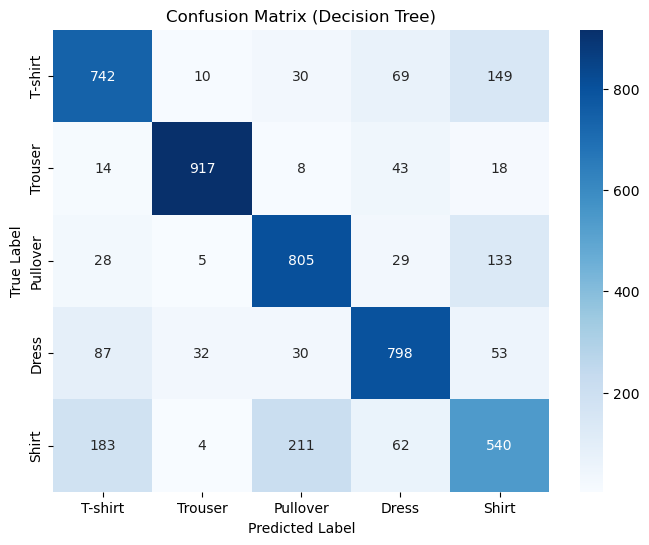

In [11]:
# Scikit-Learn Decision Tree Implementation

from sklearn.tree import DecisionTreeClassifier

# Hyperparameter Grid for Decision Tree
dt_max_depth_options = [5, 10, 15, 20]
dt_min_samples_leaf_options = [1, 2, 4, 6]

# Variables to store the best model and parameters
best_dt_score = -float('inf')
best_dt_params = {}
best_dt_model = None

# Grid search over the hyperparameters
for max_depth in dt_max_depth_options:
    for min_samples_leaf in dt_min_samples_leaf_options:
        print(f"Training Decision Tree with max_depth={max_depth}, min_samples_leaf={min_samples_leaf}")
        
        # Initialize and train the decision tree classifier
        dt_model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
        dt_model.fit(PCA_split_X_train, PCA_split_y_train)
        
        # Evaluate on validation set
        val_accuracy = dt_model.score(PCA_X_validate, PCA_y_validate)
        print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
        
        # Update the best model if current accuracy is higher
        if val_accuracy > best_dt_score:
            best_dt_score = val_accuracy
            best_dt_params = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf}
            best_dt_model = dt_model

print("\nBest Hyperparameters for Decision Tree:")
print(best_dt_params)
print(f"Best Validation Accuracy: {best_dt_score * 100:.2f}%")

# Evaluate the best model on the test set
test_accuracy = best_dt_model.score(PCA_X_test, PCA_y_test)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

# Display classification report
Y_test_pred = best_dt_model.predict(PCA_X_test)
print("\nClassification Report:")
print(classification_report(PCA_y_test, Y_test_pred))

# Plot confusion matrix
cm = confusion_matrix(PCA_y_test, Y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'],
            yticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Decision Tree)')
plt.show()


# Neural network

Epoch 1/20


2025-01-05 12:54:47.165557: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


250/250 [==============================] - 0s 789us/step - loss: 0.7283 - accuracy: 0.7207 - val_loss: 0.4664 - val_accuracy: 0.8210
Epoch 2/20
250/250 [==============================] - 0s 530us/step - loss: 0.4749 - accuracy: 0.8198 - val_loss: 0.4128 - val_accuracy: 0.8385
Epoch 3/20
250/250 [==============================] - 0s 709us/step - loss: 0.4140 - accuracy: 0.8399 - val_loss: 0.3919 - val_accuracy: 0.8400
Epoch 4/20
250/250 [==============================] - 0s 521us/step - loss: 0.3833 - accuracy: 0.8551 - val_loss: 0.3771 - val_accuracy: 0.8470
Epoch 5/20
250/250 [==============================] - 0s 519us/step - loss: 0.3694 - accuracy: 0.8615 - val_loss: 0.3711 - val_accuracy: 0.8480
Epoch 6/20
250/250 [==============================] - 0s 516us/step - loss: 0.3535 - accuracy: 0.8664 - val_loss: 0.3657 - val_accuracy: 0.8520
Epoch 7/20
250/250 [==============================] - 0s 511us/step - loss: 0.3412 - accuracy: 0.8712 - val_loss: 0.3561 - val_accuracy: 0.8580
Epo

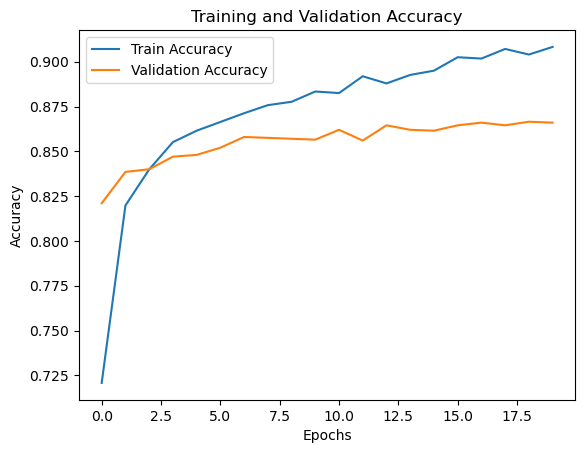

157/157 [==============================] - 0s 273us/step

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1000
           1       0.98      0.97      0.97      1000
           2       0.84      0.89      0.86      1000
           3       0.90      0.92      0.91      1000
           4       0.76      0.69      0.73      1000

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



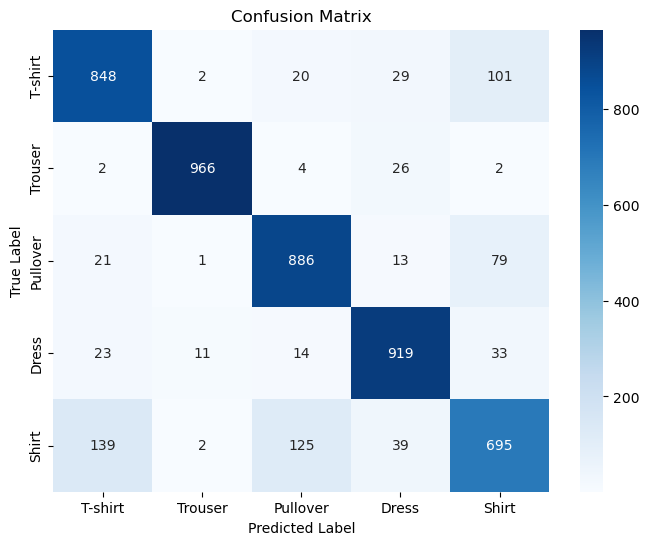

In [12]:
# Set random seed for reproducibility
tf.random.set_seed(43)


# Define the neural network model
def create_ffnn(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),  # First hidden layer with 128 neurons
        Dropout(0.3),                                              # Dropout to prevent overfitting
        Dense(64, activation='relu'),                              # Second hidden layer with 64 neurons
        Dropout(0.2),                                              # Dropout to prevent overfitting
        Dense(output_dim, activation='softmax')                    # Output layer with softmax activation
    ])
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',  # Use sparse categorical cross-entropy for integer labels
        metrics=['accuracy']
    )
    
    return model

# Create the FFNN model
input_dim = PCA_split_X_train.shape[1]  # Number of features (input dimension)
output_dim = len(np.unique(PCA_split_y_train))  # Number of unique classes (output dimension)
ffnn_model = create_ffnn(input_dim, output_dim)

# Train the model
history = ffnn_model.fit(
    PCA_split_X_train, PCA_split_y_train,
    validation_data=(PCA_X_validate, PCA_y_validate),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_acc = ffnn_model.evaluate(PCA_X_test, PCA_y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Predict on the test set
Y_test_pred = ffnn_model.predict(PCA_X_test).argmax(axis=1)

# Display classification report
print("\nClassification Report:")
print(classification_report(PCA_y_test, Y_test_pred))

# Plot confusion matrix
cm = confusion_matrix(PCA_y_test, Y_test_pred)  # Use PCA_y_test instead of PCA
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'],
            yticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



Model: Custom Decision Tree
Accuracy: 72.40%
Classification Report:
              precision  recall  f1-score   support
0              0.677909   0.804  0.735590  1000.000
1              0.937367   0.883  0.909372  1000.000
2              0.585992   0.845  0.692056  1000.000
3              0.821277   0.772  0.795876  1000.000
4              0.644898   0.316  0.424161  1000.000
accuracy       0.724000   0.724  0.724000     0.724
macro avg      0.733488   0.724  0.711411  5000.000
weighted avg   0.733488   0.724  0.711411  5000.000


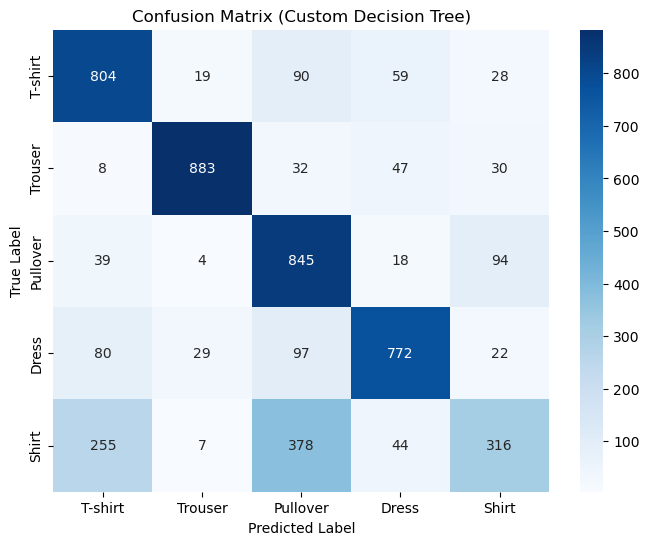


Model: Scikit-Learn Decision Tree
Accuracy: 76.04%
Classification Report:
              precision  recall  f1-score    support
0              0.703985  0.7420  0.722493  1000.0000
1              0.947314  0.9170  0.931911  1000.0000
2              0.742620  0.8050  0.772553  1000.0000
3              0.797203  0.7980  0.797601  1000.0000
4              0.604703  0.5400  0.570523  1000.0000
accuracy       0.760400  0.7604  0.760400     0.7604
macro avg      0.759165  0.7604  0.759016  5000.0000
weighted avg   0.759165  0.7604  0.759016  5000.0000


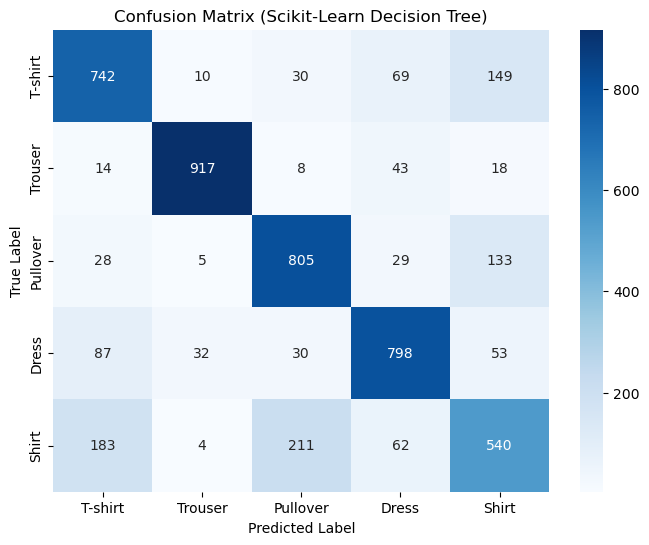


Model: Custom Feedforward Neural Network
Accuracy: 84.54%
Classification Report:
              precision  recall  f1-score    support
0              0.823289  0.8060  0.814553  1000.0000
1              0.982528  0.9560  0.969083  1000.0000
2              0.831579  0.8690  0.849878  1000.0000
3              0.862559  0.9100  0.885645  1000.0000
4              0.723629  0.6860  0.704312  1000.0000
accuracy       0.845400  0.8454  0.845400     0.8454
macro avg      0.844717  0.8454  0.844694  5000.0000
weighted avg   0.844717  0.8454  0.844694  5000.0000


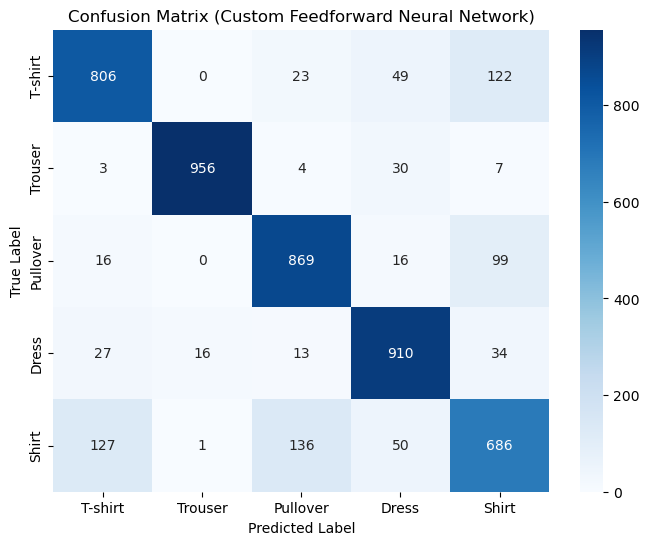

157/157 [==============================] - 0s 461us/step

Model: TensorFlow Feedforward Neural Network
Accuracy: 86.28%
Classification Report:
              precision  recall  f1-score    support
0              0.820910  0.8480  0.834235  1000.0000
1              0.983707  0.9660  0.974773  1000.0000
2              0.844614  0.8860  0.864812  1000.0000
3              0.895712  0.9190  0.907206  1000.0000
4              0.763736  0.6950  0.727749  1000.0000
accuracy       0.862800  0.8628  0.862800     0.8628
macro avg      0.861736  0.8628  0.861755  5000.0000
weighted avg   0.861736  0.8628  0.861755  5000.0000


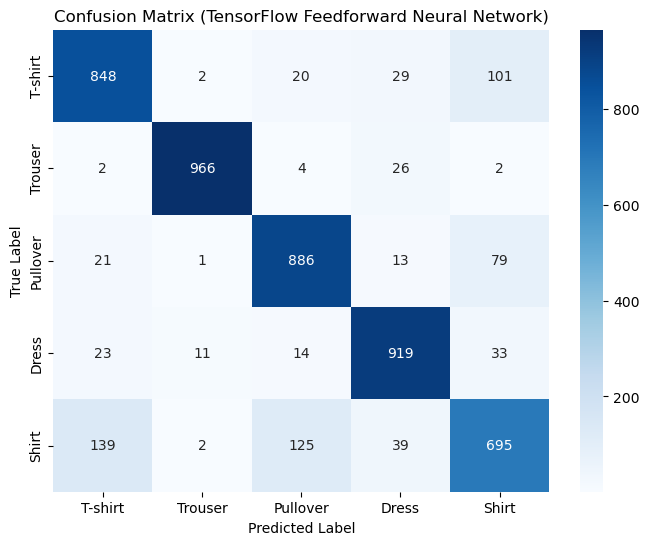

In [13]:
# Import necessary libraries
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Function to evaluate a model and display its metrics
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("Classification Report:")
    print(pd.DataFrame(report).transpose())

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'],
                yticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix ({name})')
    plt.show()


# Evaluate Custom Decision Tree Model
Y_pred_custom_dt = best_model.predict(PCA_X_test)
evaluate_model("Custom Decision Tree", PCA_y_test, Y_pred_custom_dt)

# Evaluate Scikit-Learn Decision Tree Model
Y_pred_sklearn_dt = best_dt_model.predict(PCA_X_test)
evaluate_model("Scikit-Learn Decision Tree", PCA_y_test, Y_pred_sklearn_dt)

# Evaluate Custom Feedforward Neural Network
Y_pred_custom_ffnn = final_model.predict(PCA_X_test)
evaluate_model("Custom Feedforward Neural Network", PCA_y_test, Y_pred_custom_ffnn)

# Evaluate TensorFlow Feedforward Neural Network
Y_pred_tf_ffnn = ffnn_model.predict(PCA_X_test).argmax(axis=1)
evaluate_model("TensorFlow Feedforward Neural Network", PCA_y_test, Y_pred_tf_ffnn)


In [15]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Initialize a dictionary to store evaluation results
results = {
    "Model": [],
    "Accuracy (%)": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

# Function to calculate metrics and store in the results dictionary
def evaluate_and_store_results(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred) * 100
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']
    
    results["Model"].append(model_name)
    results["Accuracy (%)"].append(accuracy)
    results["Precision"].append(precision)
    results["Recall"].append(recall)
    results["F1-Score"].append(f1_score)

# Evaluate Custom Decision Tree Model
Y_pred_custom_dt = best_model.predict(PCA_X_test)
evaluate_and_store_results("Custom Decision Tree", PCA_y_test, Y_pred_custom_dt)

# Evaluate Scikit-Learn Decision Tree Model
Y_pred_sklearn_dt = best_dt_model.predict(PCA_X_test)
evaluate_and_store_results("Scikit-Learn Decision Tree", PCA_y_test, Y_pred_sklearn_dt)

# Evaluate Custom Feedforward Neural Network
Y_pred_custom_ffnn = final_model.predict(PCA_X_test)
evaluate_and_store_results("Custom Feedforward Neural Network", PCA_y_test, Y_pred_custom_ffnn)

# Evaluate TensorFlow Feedforward Neural Network
Y_pred_tf_ffnn = ffnn_model.predict(PCA_X_test).argmax(axis=1)
evaluate_and_store_results("TensorFlow Feedforward Neural Network", PCA_y_test, Y_pred_tf_ffnn)

# Create a DataFrame to display the results
results_df = pd.DataFrame(results)
print(results_df)



157/157 [==============================] - 0s 1ms/step
                                   Model  Accuracy (%)  Precision  Recall  \
0                   Custom Decision Tree         72.40   0.733488  0.7240   
1             Scikit-Learn Decision Tree         76.04   0.759165  0.7604   
2      Custom Feedforward Neural Network         84.54   0.844717  0.8454   
3  TensorFlow Feedforward Neural Network         86.28   0.861736  0.8628   

   F1-Score  
0  0.711411  
1  0.759016  
2  0.844694  
3  0.861755  
